# 因子分析案例

### 小组成员：栾沛遥 冯梦瑶 骆喜
### 2025年4月17日

### （一）数据集简介：

人格特质数据集基于“大五人格理论”，用于测量个体在五个主要人格维度上的表现：外向性、神经质、开放性、宜人性和尽责性。数据集包含2800个观测值，适用于心理学研究和人格分析。

#### 1.因子分析在人格特质数据上的应用
因子分析本质上是降维的过程，就是通过25个变量来进行降维，发现在相关性很高的变量背后有哪些共同的因子在驱动，确定因子个数，提取因子，进行因子分析。而我们刚才提到的，个体在五个主要人格维度上的表现：外向性、神经质、开放性、宜人性和尽责性就是25个变量后的驱动因子，我们小组将对人格特质数据集进行因子分析，从而验证这个结论！


#### 2.变量含义：

宜人性（Agreeableness）
A1: 对他人的感受漠不关心。
A2: 关心他人的幸福。
A3: 知道如何安慰他人。
A4: 喜欢孩子。
A5: 让人感到自在。

尽责性（Conscientiousness）
C1: 对工作一丝不苟。
C2: 坚持直到一切完美。
C3: 按计划做事。
C4: 做事情半途而废。
C5: 浪费时间。

外向性（Extraversion）
E1: 不多说话。
E2: 难以接近他人。
E3: 知道如何吸引人。
E4: 容易交朋友。
E5: 主动承担责任。

神经质（Neuroticism）
N1: 容易生气。
N2: 容易烦躁。
N3: 情绪波动频繁。
N4: 经常感到沮丧。
N5: 容易恐慌。

开放性（Openness）
O1: 思路开阔。
O2: 避免阅读困难的材料。
O3: 将对话提升到更高层次。
O4: 花时间反思。
O5: 不深入研究主题。

#### 3.变量中数值含义：
数据集各个变量的数值1-6来源于参与者对问卷中相应陈述的评分，这种评分机制是基于李克特量表，这是一种常见的心理学和问卷调查工具，
在人格特质数据集中，参与者根据自己的实际情况，选择最符合自己感受的选项，
每个选项对应一个数值（1-6），数值越高表示对陈述的认同程度越高

6种评分（1-6分）：

1分——非常不同意

2分——不同意

3分——稍微不同意

4分——稍微同意

5分——同意

6分——非常同意

#### 4.人格特质数据集因子分析的意义：
因子分析用于识别数据中的潜在结构，将多个相关变量归为少数几个因子。对于人格特质数据集，因子分析有助于
将25个变量归纳为几个主要因子。验证理论确认数据是否符合大五人格理论。
通过因子载荷矩阵明确每个变量在因子上的贡献。可以为心理学研究、职业选择和团队建设提供依据。
因子分析能有效揭示数据的内在联系，帮助研究者更好地理解人格特质的分布和影响。

### （二）数据集来源：https://vincentarelbundock.github.io/Rdatasets/csv/psych/bfi.csv


## 一.因子分析建模

#### 数据预处理：
导入数据，选择人格特质相关的前25个变量，后三个变量是关于参与者信息的，对因子分析没有帮助，所以删去；发现数据存在缺失值的情况，直接删除对应行数据。

In [54]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

import matplotlib as plt

import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.sans-serif'] = ['SimHei']  
plt.rcParams['axes.unicode_minus'] = False  

data = pd.read_csv("bfi.csv")

#选择人格特质相关的前25个变量，后三个变量是关于参与者信息的，对因子分析没有帮助，所以删去
data = data.iloc[:, :26]
data = data.drop(columns=data.columns[0])  #删除第一列

#删除包含缺失值的行
data = data.dropna()

data.head()

,A1,A2,A3,A4,A5,C1,C2,C3,C4,C5,...,N1,N2,N3,N4,N5,O1,O2,O3,O4,O5
0,2.0,4.0,3.0,4.0,4.0,2.0,3.0,3.0,4.0,4.0,...,3.0,4.0,2.0,2.0,3.0,3.0,6,3.0,4.0,3.0
1,2.0,4.0,5.0,2.0,5.0,5.0,4.0,4.0,3.0,4.0,...,3.0,3.0,3.0,5.0,5.0,4.0,2,4.0,3.0,3.0
2,5.0,4.0,5.0,4.0,4.0,4.0,5.0,4.0,2.0,5.0,...,4.0,5.0,4.0,2.0,3.0,4.0,2,5.0,5.0,2.0
3,4.0,4.0,6.0,5.0,5.0,4.0,4.0,3.0,5.0,5.0,...,2.0,5.0,2.0,4.0,1.0,3.0,3,4.0,3.0,5.0
4,2.0,3.0,3.0,4.0,5.0,4.0,4.0,5.0,3.0,2.0,...,2.0,3.0,4.0,4.0,3.0,3.0,3,4.0,3.0,3.0


#### 特征相关性分析：
绘制特征相关性热力图，可以发现某些特征之间存在相关性

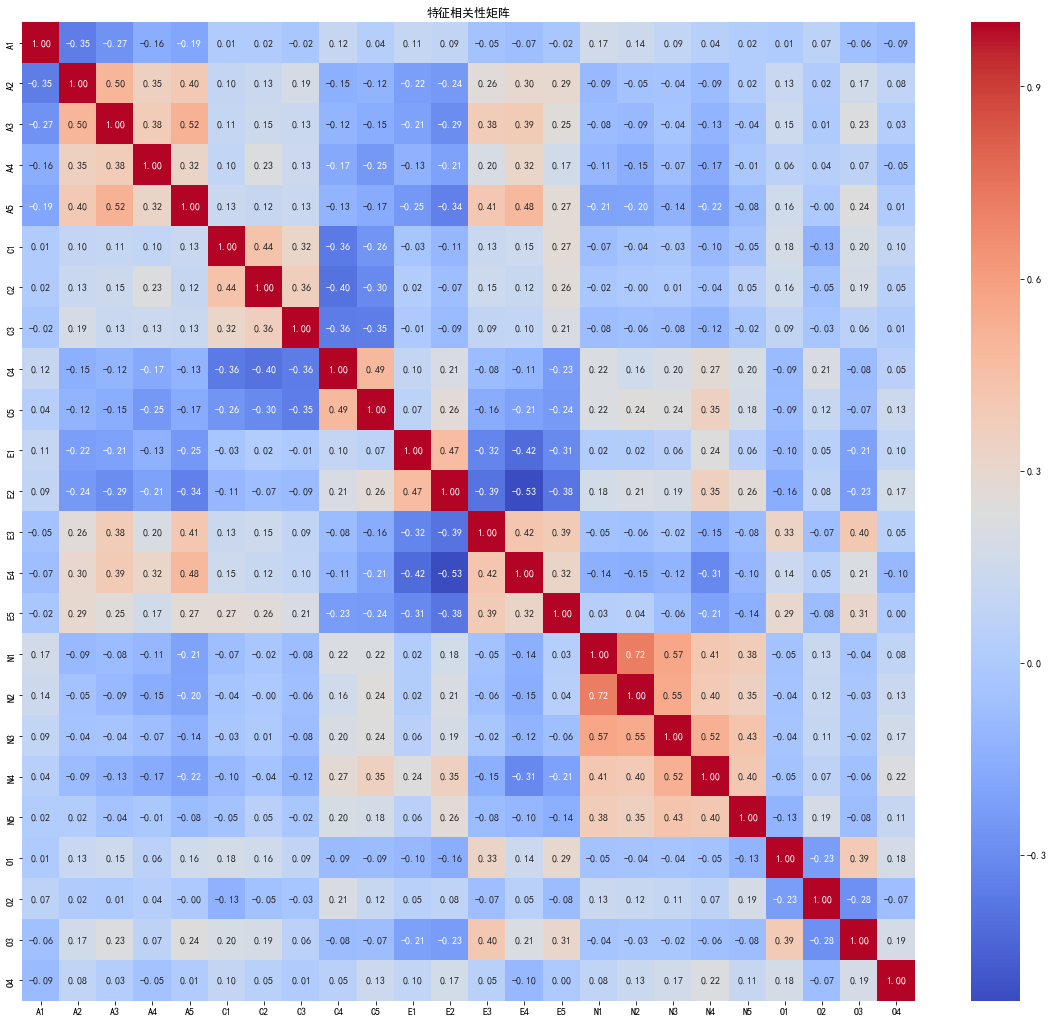

In [38]:
import seaborn as sns

plt.figure(figsize=(20, 18))

# 选择所有行和除第一列外的所有列

sns.heatmap(data.iloc[:, 1:].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('特征相关性矩阵')
plt.show()

#### Bartlett 和KMO检验
Bartlett的检验p值较小，说明显著，数据集适合进行因子分析

KMO检验的值大于0.8，说明数据集适合进行因子分析

两种检验都说明此数据集有进行因子分析的条件，所以可以进行因子分析

In [73]:
from factor_analyzer.factor_analyzer import calculate_kmo, calculate_bartlett_sphericity

#数据标准化
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data)

kmo_score = calculate_kmo(data_scaled)
chi_square, p_value = calculate_bartlett_sphericity(data_scaled)

print(f"KMO Score: {kmo_score}")
print(f"Bartlett's Test p-value: {p_value}")

KMO Score: (array([0.7540716 , 0.83643198, 0.87020241, 0.87804164, 0.90355905,
       0.84336264, 0.7958161 , 0.85197217, 0.8265898 , 0.86411332,
       0.83813017, 0.88388974, 0.89704594, 0.87740109, 0.89339981,
       0.7794802 , 0.78039095, 0.86239667, 0.88526811, 0.86024031,
       0.8586864 , 0.78033877, 0.84445746, 0.77017696, 0.76159382]), 0.8486452309468394)
Bartlett's Test p-value: 0.0


####  因子提取（确定因子数量）
##### 碎石图
使用FactorAnalyzer库进行因子提取，并通过碎石图选择合适的因子数量。

选择特征值大于某一阈值的因子数量，所以根据碎石图，可以确定选择因子的数量为5

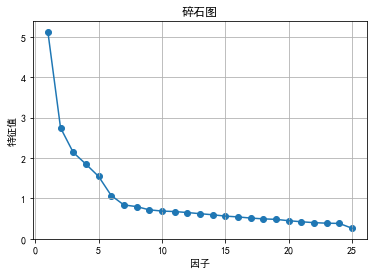

特征值： [5.13431118 2.75188667 2.14270195 1.85232761 1.54816285 1.07358247
 0.83953893 0.79920618 0.71898919 0.68808879 0.67637336 0.65179984
 0.62325295 0.59656284 0.56309083 0.54330533 0.51451752 0.49450315
 0.48263952 0.448921   0.42336611 0.40067145 0.38780448 0.38185679
 0.26253902]
特征向量： [ 4.59960574e+00  2.26808647e+00  1.54873693e+00  1.21837903e+00
  9.55670585e-01  4.59049913e-01  2.38121756e-01  1.90831736e-01
  1.00097666e-01  8.74325104e-02  6.42831077e-02  3.16939003e-02
 -4.01967368e-03 -2.19065565e-02 -4.82903159e-02 -5.40934670e-02
 -6.05233193e-02 -7.72732164e-02 -8.74022975e-02 -1.04484882e-01
 -1.18911062e-01 -1.23542394e-01 -1.40463488e-01 -1.53362949e-01
 -1.77236673e-01]


In [55]:
from factor_analyzer import FactorAnalyzer
import matplotlib.pyplot as plt


#构建因子分析模型，提取5个因子
fa = FactorAnalyzer(n_factors=5, rotation="varimax") 
fa.fit(data)

#获取特征值，特征向量
ev, v = fa.get_eigenvalues()

#碎石图
plt.scatter(range(1, data.shape[1]+1), ev)
plt.plot(range(1, data.shape[1]+1), ev)
plt.title('碎石图')
plt.xlabel('因子')
plt.ylabel('特征值')
plt.grid()
plt.show()

print("特征值：",ev)
print("特征向量：",v)

#### 构建因子分析模型
构建一个因子分析模型，提取5个因子并使用 Varimax 旋转。

Varimax 旋转是一种常用的正交旋转方法，其目的是优化因子载荷矩阵的结构，
通过最大化每个因子上的高载荷变量的数量，同时尽量减少低载荷变量的数量，使得每个因子能够更明确地代表某些变量的共同特征。


In [56]:
# 构建因子分析模型
fa = FactorAnalyzer(n_factors=5, rotation='varimax')
fa.fit(data)

# 获取因子载荷矩阵
loadings = fa.loadings_
print("因子载荷矩阵：")
print(loadings)

因子载荷矩阵：
[[ 0.11112641  0.04046493  0.02279796 -0.42816554 -0.07793074]
 [ 0.029588    0.21371606  0.13903739  0.62694553  0.06213921]
 [ 0.00935691  0.31784809  0.10933115  0.65074261  0.05619584]
 [-0.06647574  0.20456624  0.23058374  0.43562383 -0.1127004 ]
 [-0.12211317  0.39303367  0.08786921  0.53708686  0.0667076 ]
 [ 0.01041556  0.07018423  0.54582379  0.03887794  0.20958365]
 [ 0.08957412  0.0332704   0.64873118  0.10278247  0.11543389]
 [-0.03085502  0.02390651  0.55703585  0.11157762 -0.00518271]
 [ 0.24041008 -0.06498371 -0.63380554 -0.03749823 -0.107535  ]
 [ 0.29031777 -0.1763948  -0.56246672 -0.04752477  0.03682235]
 [ 0.04281888 -0.5748346   0.03314352 -0.10481258 -0.05879528]
 [ 0.24474268 -0.67873071 -0.10248265 -0.11251716 -0.04200997]
 [ 0.02418041  0.53681627  0.08301031  0.2579065   0.28087733]
 [-0.11561383  0.64683266  0.1020229   0.3061013  -0.07342224]
 [ 0.0361453   0.50406876  0.31289947  0.09035398  0.21373932]
 [ 0.78680746  0.07892269 -0.04599687 -0.216363

#### 因子载荷矩阵解释
将因子载荷矩阵转换为DataFrame，便于查看每个变量在因子上的载荷。

In [58]:
loadings_df = pd.DataFrame(loadings, columns=['Factor1', 'Factor2', 'Factor3','Factor4', 'Factor5'], index=data.columns)
print(loadings_df)

     Factor1   Factor2   Factor3   Factor4   Factor5
A1  0.111126  0.040465  0.022798 -0.428166 -0.077931
A2  0.029588  0.213716  0.139037  0.626946  0.062139
A3  0.009357  0.317848  0.109331  0.650743  0.056196
A4 -0.066476  0.204566  0.230584  0.435624 -0.112700
A5 -0.122113  0.393034  0.087869  0.537087  0.066708
C1  0.010416  0.070184  0.545824  0.038878  0.209584
C2  0.089574  0.033270  0.648731  0.102782  0.115434
C3 -0.030855  0.023907  0.557036  0.111578 -0.005183
C4  0.240410 -0.064984 -0.633806 -0.037498 -0.107535
C5  0.290318 -0.176395 -0.562467 -0.047525  0.036822
E1  0.042819 -0.574835  0.033144 -0.104813 -0.058795
E2  0.244743 -0.678731 -0.102483 -0.112517 -0.042010
E3  0.024180  0.536816  0.083010  0.257906  0.280877
E4 -0.115614  0.646833  0.102023  0.306101 -0.073422
E5  0.036145  0.504069  0.312899  0.090354  0.213739
N1  0.786807  0.078923 -0.045997 -0.216363 -0.084704
N2  0.754109  0.027301 -0.030568 -0.193744 -0.010304
N3  0.731721 -0.061430 -0.067084 -0.027712 -0.

## 二.因子模型效果评估

#### 共同度（公因子方差）

表示因子分析中每个变量的方差中可以被因子解释的部分

公因子方差是通过因子载荷矩阵计算的，因子载荷矩阵中的每个元素表示变量与因子之间的相关性。
公因子方差是因子载荷矩阵中对应变量的因子载荷的平方和，就是因子载荷矩阵的第i行的元素的平方和

#### 实际意义
数据集中，第一个变量A1的公因子方差为 0.20，说明其 20% 的方差可以被因子解释。
第二个变量A2的公因子方差为 0.46，说明其 46% 的方差可以被因子解释

公因子方差可以帮助判断因子模型对变量的解释能力。如果大部分变量的公因子方差较高，说明因子模型能够很好地解释数据的结构。

In [59]:
fa = FactorAnalyzer(n_factors=5, rotation="varimax") 
fa.fit(data)
pd.DataFrame(fa.get_communalities(),index=data.columns, columns=["共同度"])

,共同度
A1,0.203905
A2,0.462803
A3,0.539692
A4,0.301905
A5,0.470020
C1,0.348395
C2,0.453872
C3,0.324289
C4,0.476699
C5,0.435383


#### 提取因子方差的统计信息

因子方差是因子对数据方差的贡献量。因子分析的目标是提取少量因子来解释数据中大部分的方差。因子方差的统计信息可以帮助我们评估因子模型的效果。

##### 1.总方差（Total Variance）：

因子对数据方差的总贡献，就是因子载荷矩阵的第i列元素的平方和

Factor 1 对数据方差的贡献最大为 2.709633，Factor 2 、Factor 3、Factor 4 和 Factor 5 的贡献依次递减。

##### 2.方差比例（Variance Proportion）：
每个因子对总方差的贡献比例。

Factor 1 解释了总方差的 10.84%，Factor 2 、Factor 3、Factor 4 和 Factor 5 的解释比例依次递减。

##### 3.累计方差比例（Cumulative Variance Proportion）：
前 k 个因子的方差比例之和

五个因子累计解释了总方差的 42.36%。这意味着因子模型能够解释数据中约 42.36% 的方差
累计方差比例达到 70% 或更高被认为是较好的模型。如果累计方差比例较低，可能需要重新考虑因子的数量或模型的结构。

In [60]:
import pandas as pd

factor_variance = fa.get_factor_variance()
df_factor_variance = pd.DataFrame(
    factor_variance,
    index=["总方差", "方差比例", "累计方差比例"],
    columns=["Factor 1", "Factor 2", "Factor 3", "Factor 4", "Factor 5"]
)

df_factor_variance

,Factor 1,Factor 2,Factor 3,Factor 4,Factor 5
总方差,2.709633,2.473090,2.041106,1.844498,1.522153
方差比例,0.108385,0.098924,0.081644,0.073780,0.060886
累计方差比例,0.108385,0.207309,0.288953,0.362733,0.423619


## 三.因子分析的降维结果

#### 因子载荷矩阵可视化
使用热力图展示因子载荷矩阵。

因子载荷是第i个变量与第j个公共因子的相关系数，反映的是第i个变量和第j个公共因子之间的重要性。
绝对值越大，表示相关性的密切程度越高。

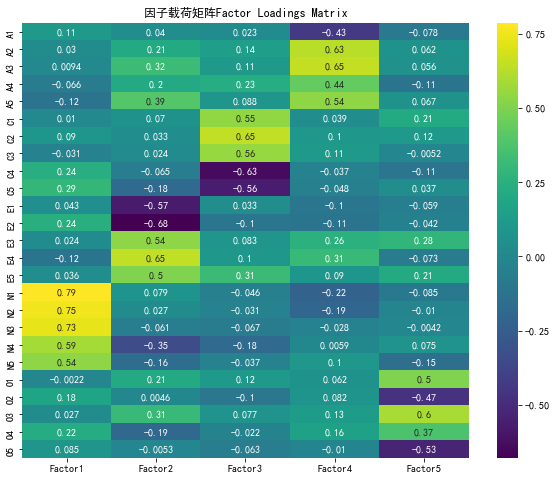

In [61]:
import seaborn as sns

plt.figure(figsize=(10, 8))
#sns.heatmap(np.abs(loadings_df), annot=True, cmap='viridis')
sns.heatmap(loadings_df, annot=True, cmap='viridis')
plt.title('因子载荷矩阵Factor Loadings Matrix')
plt.show()

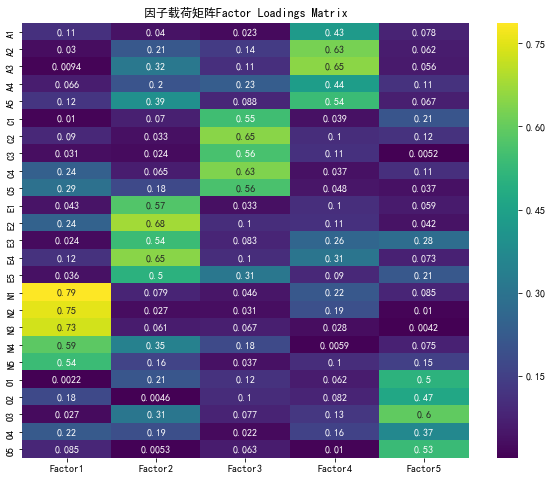

In [62]:
import seaborn as sns

plt.figure(figsize=(10, 8))
sns.heatmap(np.abs(loadings_df), annot=True, cmap='viridis')
#sns.heatmap(loadings_df, annot=True, cmap='viridis')
plt.title('因子载荷矩阵Factor Loadings Matrix')
plt.show()

#### 因子命名
由上图可以看出，Factor1与变量N1到N5的相关性很高，即Factor1可以解释变量N1到N5

对应大五人格理论，将Factor1命名为神经质;

同理，将Factor2命名为外向性；将Factor3命名为尽责性；将Factor4命名为宜人性；将Factor5命名为开放性

#### 因子得分计算

因子得分表提供了每个观测在各个因子上的得分，
帮助我们理解观测在因子上的表现。通过分析因子得分，可以进一步解释因子的含义和观测的特征。

因子得分可以用于替代原始数据进行后续分析，因为它们保留了原始数据的主要结构，同时减少了数据的维度。

##### 因子得分用途：
因子得分可以用来进行聚类分析、回归分析、可视化和异常检测等。


In [63]:
data_factor_analysis=pd.DataFrame(fa.transform(data),columns=['Factor1神经质', 'Factor2外向性', 'Factor3尽责性',
                                                              'Factor4宜人性', 'Factor5开放性'])
data_factor_analysis.head()

,Factor1神经质,Factor2外向性,Factor3尽责性,Factor4宜人性,Factor5开放性
0,-0.439830,0.103897,-1.216713,-0.696215,-1.519449
1,0.084369,0.559311,-0.601521,-0.189341,-0.248384
2,0.520534,0.318235,0.025646,-0.751136,0.204503
3,-0.197064,0.057696,-1.019263,0.064286,-1.029492
4,-0.329835,0.408754,-0.058843,-0.820454,-0.691042


## 四.降维结果的后续分析

#### 因子得分可视化
绘制因子得分的散点图，展示样本在因子上的分布。

可视化效果并没有很好，选用热力图将因子得分可视化！

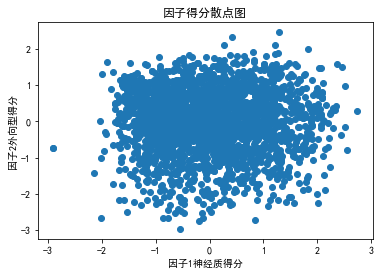

In [64]:
plt.scatter(factor_scores[:, 0], factor_scores[:, 1])
plt.xlabel('因子1神经质得分')
plt.ylabel('因子2外向型得分')
plt.title('因子得分散点图')
plt.show()

##### 因子得分热力图

可以帮助我们理解每个观测在各个因子上的表现，进而对每个观测进行分析。

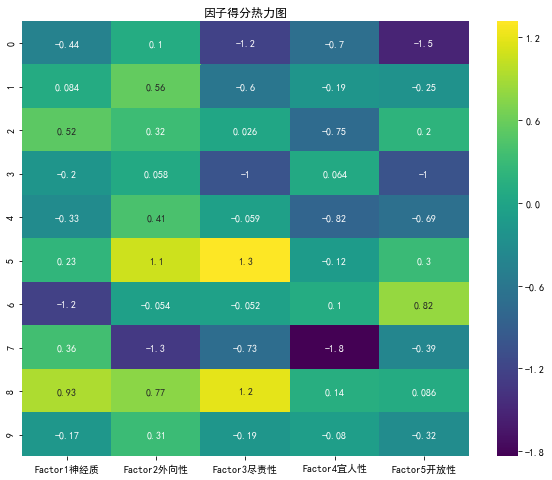

In [68]:
import seaborn as sns

#选择前10个观测进行热图可视化
subset = data_factor_analysis.head(10)

plt.figure(figsize=(10, 8))
column_names = ['Factor1神经质', 'Factor2外向性', 'Factor3尽责性', 'Factor4宜人性', 'Factor5开放性']
sns.heatmap(subset, annot=True, cmap='viridis', xticklabels=column_names)
                                                       
plt.title('因子得分热力图')
plt.show()

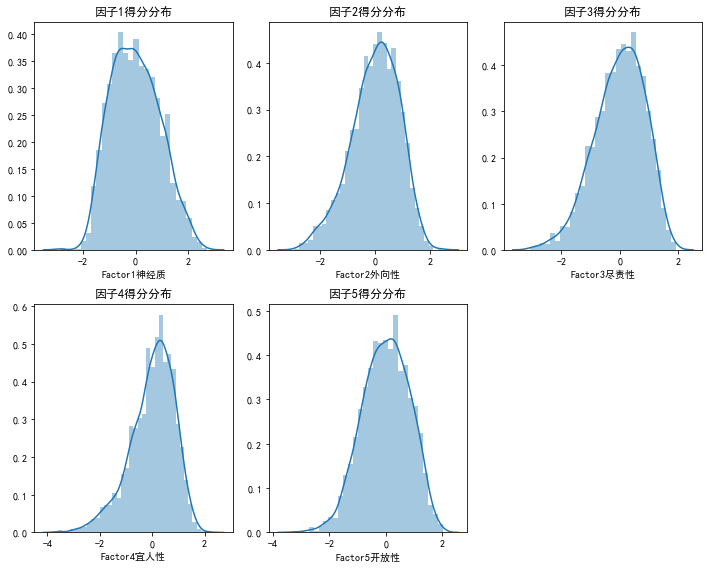

In [69]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from factor_analyzer import FactorAnalyzer

fa = FactorAnalyzer(n_factors=5, rotation="varimax")
fa.fit(data)

# 计算因子得分
factor_scores = fa.transform(data)
data_factor_analysis = pd.DataFrame(factor_scores,columns = ['Factor1神经质', 'Factor2外向性', 'Factor3尽责性',
                                                                  'Factor4宜人性', 'Factor5开放性'])
fig, axes = plt.subplots(2, 3, figsize=(10, 8))
sns.distplot(data_factor_analysis['Factor1神经质'], kde=True, ax=axes[0, 0])
axes[0, 0].set_xlabel('Factor1神经质')
axes[0, 0].set_title('因子1得分分布')

sns.distplot(data_factor_analysis['Factor2外向性'], kde=True, ax=axes[0, 1])
axes[0, 1].set_xlabel('Factor2外向性')
axes[0, 1].set_title('因子2得分分布')

sns.distplot(data_factor_analysis['Factor3尽责性'], kde=True, ax=axes[0, 2])
axes[0, 2].set_xlabel('Factor3尽责性')
axes[0, 2].set_title('因子3得分分布')

sns.distplot(data_factor_analysis['Factor4宜人性'], kde=True, ax=axes[1, 0])
axes[1, 0].set_xlabel('Factor4宜人性')
axes[1, 0].set_title('因子4得分分布')

sns.distplot(data_factor_analysis['Factor5开放性'], kde=True, ax=axes[1, 1])
axes[1, 1].set_xlabel('Factor5开放性')
axes[1, 1].set_title('因子5得分分布')

fig.delaxes(axes[1, 2])
plt.tight_layout()
plt.show()

### 总结：


通过因子分析建模、因子模型评估、因子分析降维结果、降维结果后续分析这几个部分，
可以将数据集中的25个变量降维，找到5个因子来表示，验证了大五人格理论，并且因子得分可以用于后续分析！